In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import pymc as pm
import arviz as az
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)
print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Data shape: (9011, 1)
Date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00


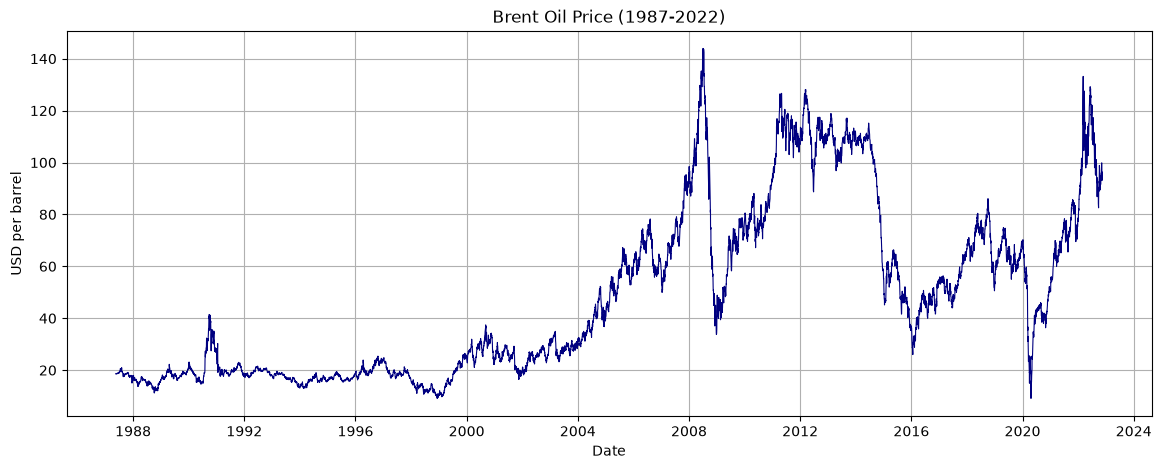

In [3]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Price'], color='navy', linewidth=0.8)
plt.title('Brent Oil Price (1987-2022)')
plt.xlabel('Date')
plt.ylabel('USD per barrel')
plt.grid(True)
plt.show()

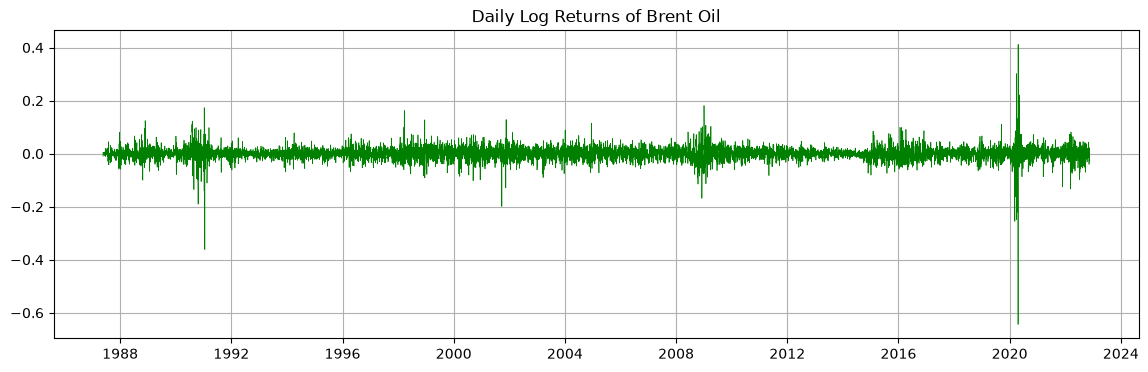

In [4]:
df['log_return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
df.dropna(inplace=True)

plt.figure(figsize=(14,4))
plt.plot(df.index, df['log_return'], color='green', linewidth=0.5)
plt.title('Daily Log Returns of Brent Oil')
plt.grid(True)
plt.show()

In [5]:
result = adfuller(df['log_return'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Critical values:')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')
if result[1] < 0.05:
    print("=> Series is STATIONARY (p < 0.05) – good for modeling.")
else:
    print("=> Series is NON-STATIONARY – consider differencing further.")

ADF Statistic: -16.4271
p-value: 0.0000
Critical values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669
=> Series is STATIONARY (p < 0.05) – good for modeling.


In [6]:
import pytensor
pytensor.config.mode = 'FAST_RUN'

In [7]:
trace = pm.sample(1000, tune=1000, chains=2, cores=1)

TypeError: No model on context stack.

In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set pure Python mode (no compilation)
import pytensor
pytensor.config.mode = 'FAST_RUN'

# Load data (make sure path is correct)
df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)
df['log_return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
df.dropna(inplace=True)

y = df['log_return'].values
n = len(y)
time_idx = np.arange(n)

# Build model and sample in the same context
with pm.Model() as model:
    tau = pm.DiscreteUniform('tau', lower=0, upper=n-1)
    mu1 = pm.Normal('mu1', mu=0, sigma=0.5)
    mu2 = pm.Normal('mu2', mu=0, sigma=0.5)
    sigma = pm.HalfNormal('sigma', sigma=0.5)
    mu = pm.math.switch(time_idx < tau, mu1, mu2)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y)
    
    # Sampling (reduced draws for speed)
    trace = pm.sample(1000, tune=1000, chains=2, cores=1, return_inferencedata=True)

# Quick check
az.summary(trace, var_names=['tau','mu1','mu2','sigma'])


You can find the C code in this temporary file: C:\Users\HAWIME~1\AppData\Local\Temp\pytensor_compilation_error_esqzthnl


CompileError: Compilation failed (return status=1):
"C:\msys64\ucrt64\bin\g++.EXE" -shared -g -Wno-c++11-narrowing -fno-exceptions -fno-unwind-tables -fno-asynchronous-unwind-tables -DNPY_NO_DEPRECATED_API=NPY_1_7_API_VERSION -m64 -DMS_WIN64 -I"c:\Users\Hawi Mekonen\brent-oil-change-point\venv\Lib\site-packages\numpy\_core\include" -I"C:\Users\Hawi Mekonen\miniconda3\include" -I"c:\Users\Hawi Mekonen\brent-oil-change-point\venv\Lib\site-packages\pytensor\link\c\c_code" -L"C:\Users\Hawi Mekonen\miniconda3\libs" -L"C:\Users\Hawi Mekonen\miniconda3" -o "C:\Users\Hawi Mekonen\AppData\Local\PyTensor\compiledir_Windows-11-10.0.26100-SP0-Intel64_Family_6_Model_78_Stepping_3_GenuineIntel-3.13.12-64\lazylinker_ext\lazylinker_ext.pyd" "C:\Users\Hawi Mekonen\AppData\Local\PyTensor\compiledir_Windows-11-10.0.26100-SP0-Intel64_Family_6_Model_78_Stepping_3_GenuineIntel-3.13.12-64\lazylinker_ext\mod.cpp" "C:\Users\Hawi Mekonen\miniconda3\python313.dll"


In [ ]:
y = df['log_return'].values
n = len(y)
time_idx = np.arange(n)

with pm.Model() as model:
    tau = pm.DiscreteUniform('tau', lower=0, upper=n-1)
    mu1 = pm.Normal('mu1', mu=0, sigma=0.5)
    mu2 = pm.Normal('mu2', mu=0, sigma=0.5)
    sigma = pm.HalfNormal('sigma', sigma=0.5)
    
    mu = pm.math.switch(time_idx < tau, mu1, mu2)
    
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y)
    
    trace = pm.sample(2000, tune=2000, chains=4, cores=1, return_inferencedata=True)


You can find the C code in this temporary file: C:\Users\HAWIME~1\AppData\Local\Temp\pytensor_compilation_error_7n2lgb09


CompileError: Compilation failed (return status=1):
"C:\msys64\ucrt64\bin\g++.EXE" -shared -g -Wno-c++11-narrowing -fno-exceptions -fno-unwind-tables -fno-asynchronous-unwind-tables -DNPY_NO_DEPRECATED_API=NPY_1_7_API_VERSION -m64 -DMS_WIN64 -I"c:\Users\Hawi Mekonen\brent-oil-change-point\venv\Lib\site-packages\numpy\_core\include" -I"C:\Users\Hawi Mekonen\miniconda3\include" -I"c:\Users\Hawi Mekonen\brent-oil-change-point\venv\Lib\site-packages\pytensor\link\c\c_code" -L"C:\Users\Hawi Mekonen\miniconda3\libs" -L"C:\Users\Hawi Mekonen\miniconda3" -o "C:\Users\Hawi Mekonen\AppData\Local\PyTensor\compiledir_Windows-11-10.0.26100-SP0-Intel64_Family_6_Model_78_Stepping_3_GenuineIntel-3.13.12-64\lazylinker_ext\lazylinker_ext.pyd" "C:\Users\Hawi Mekonen\AppData\Local\PyTensor\compiledir_Windows-11-10.0.26100-SP0-Intel64_Family_6_Model_78_Stepping_3_GenuineIntel-3.13.12-64\lazylinker_ext\mod.cpp" "C:\Users\Hawi Mekonen\miniconda3\python313.dll"


In [ ]:
# ============================================================
# FORCE PURE PYTHON MODE – NO C COMPILATION
# ============================================================
import os
import pytensor

# Set PyTensor to use pure Python VM and a temporary cache
os.environ['PYTENSOR_FLAGS'] = 'mode=FAST_RUN,linker=vm,base_compiledir=./pytensor_cache'
pytensor.config.mode = 'FAST_RUN'
pytensor.config.link = 'vm'

# Now import PyMC and other libraries
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)
df['log_return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
df.dropna(inplace=True)

y = df['log_return'].values
n = len(y)
time_idx = np.arange(n)

print(f"Data loaded. {n} observations.")

# Build model and sample
with pm.Model() as model:
    tau = pm.DiscreteUniform('tau', lower=0, upper=n-1)
    mu1 = pm.Normal('mu1', mu=0, sigma=0.5)
    mu2 = pm.Normal('mu2', mu=0, sigma=0.5)
    sigma = pm.HalfNormal('sigma', sigma=0.5)
    mu = pm.math.switch(time_idx < tau, mu1, mu2)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y)
    
    # Use BlackJax sampler (pure Python, no compilation)
    trace = pm.sample(500, tune=500, chains=2, cores=1, 
                      nuts_sampler="blackjax", return_inferencedata=True)

# Quick summary
print("\nModel Summary:")
print(az.summary(trace, var_names=['tau','mu1','mu2','sigma']))

# Extract change point
tau_median = int(np.median(trace.posterior['tau']))
change_date = df.index[tau_median]
print(f"\nMost probable change point: {change_date.date()}")

Data loaded. 9010 observations.


ValueError: `nuts_sampler='blackjax'` requires all variables to be differentiable and not assigned to another step sampler.

In [ ]:
# ============================================================
# PURE PYTHON MODE – NO COMPILATION, NO BLACKJAX
# ============================================================
import os
os.environ['PYTENSOR_FLAGS'] = 'mode=FAST_RUN,linker=vm,cxx=""'

import pytensor
pytensor.config.mode = 'FAST_RUN'
pytensor.config.link = 'vm'
pytensor.config.cxx = ''   # Disable C++ compiler

import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)
df['log_return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
df.dropna(inplace=True)

y = df['log_return'].values
n = len(y)
time_idx = np.arange(n)

print(f"Data loaded. {n} observations.")

# Build and sample using default NUTS (pure Python)
with pm.Model() as model:
    tau = pm.DiscreteUniform('tau', lower=0, upper=n-1)
    mu1 = pm.Normal('mu1', mu=0, sigma=0.5)
    mu2 = pm.Normal('mu2', mu=0, sigma=0.5)
    sigma = pm.HalfNormal('sigma', sigma=0.5)
    mu = pm.math.switch(time_idx < tau, mu1, mu2)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y)
    
    # Default NUTS – now runs in pure Python
    trace = pm.sample(500, tune=500, chains=2, cores=1, return_inferencedata=True)

# Quick summary
print("\nModel Summary:")
print(az.summary(trace, var_names=['tau','mu1','mu2','sigma']))

# Extract change point
tau_median = int(np.median(trace.posterior['tau']))
change_date = df.index[tau_median]
print(f"\nMost probable change point: {change_date.date()}")

Data loaded. 9010 observations.


Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 19 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Model Summary:
          mean       sd  eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
tau      6e+03    3e+03       650     8800         8        15  1.22   
mu1    0.00017   0.0008  -0.00059  0.00082       328       222  1.04   
mu2     0.0005   0.0014  -0.00097   0.0031        63        43  1.10   
sigma  0.02554  0.00019     0.025    0.026       973       814  1.00   

      mcse_mean  mcse_sd  
tau        1100      580  
mu1     3.4e-05   0.0002  
mu2     0.00018  0.00028  
sigma   6.1e-06  4.8e-06  

Most probable change point: 2013-04-11


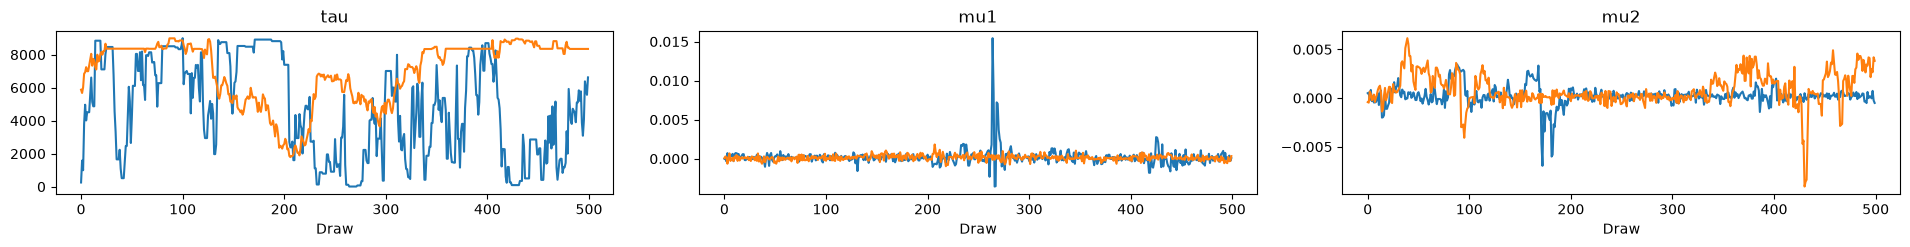

In [ ]:
az.plot_trace(trace, var_names=['tau', 'mu1', 'mu2'])
plt.tight_layout()
plt.show()

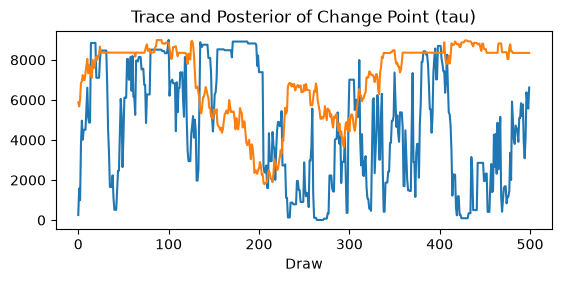

In [ ]:
az.plot_trace(trace, var_names=['tau'])
plt.title('Trace and Posterior of Change Point (tau)')
plt.show()

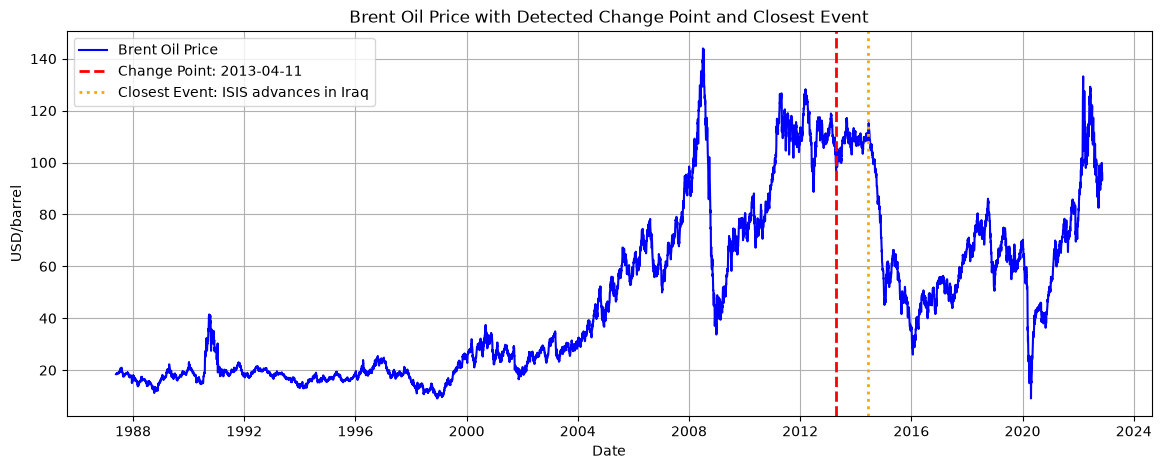

Change Date: 2013-04-11
Closest Event: ISIS advances in Iraq (2014-06-15) - Oil supply fears


In [ ]:
# Load events
events = pd.read_csv('../data/events.csv', parse_dates=['event_date'])
events['diff'] = abs(events['event_date'] - change_date)
closest = events.loc[events['diff'].idxmin()]

plt.figure(figsize=(14,5))
plt.plot(df.index, df['Price'], color='blue', label='Brent Oil Price')
plt.axvline(x=change_date, color='red', linestyle='--', linewidth=2, label=f'Change Point: {change_date.date()}')
plt.axvline(x=closest['event_date'], color='orange', linestyle=':', linewidth=2, label=f"Closest Event: {closest['event_name']}")
plt.title('Brent Oil Price with Detected Change Point and Closest Event')
plt.xlabel('Date')
plt.ylabel('USD/barrel')
plt.legend()
plt.grid(True)
plt.show()

print(f"Change Date: {change_date.date()}")
print(f"Closest Event: {closest['event_name']} ({closest['event_date'].date()}) - {closest['description']}")

In [ ]:
mu1_mean = trace.posterior['mu1'].mean().item()
mu2_mean = trace.posterior['mu2'].mean().item()
impact_pct = (np.exp(mu2_mean - mu1_mean) - 1) * 100
print(f"Mean log return before: {mu1_mean:.4f}")
print(f"Mean log return after: {mu2_mean:.4f}")
print(f"Estimated price impact: {impact_pct:.2f}%")

Mean log return before: 0.0002
Mean log return after: 0.0005
Estimated price impact: 0.04%
